In [1]:
import matplotlib.pyplot as plt
import os
import pandas as pd
import plotly.express as px

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
train_df = pd.read_csv(os.path.join('..', 'data', 'raw', 'train.csv'))
test_df = pd.read_csv(os.path.join('..', 'data', 'raw', 'test.csv'))

In [3]:
print(train_df.shape)

duplicated_rows = train_df[train_df.duplicated()].shape[0]
print('duplicated_rows =', duplicated_rows)

duplicated_rows = train_df[train_df.duplicated(subset=train_df.columns.difference(['Year']))].shape[0]
print('duplicated_rows (excluding date column) =', duplicated_rows)

(16165, 54)
duplicated_rows = 0
duplicated_rows (excluding date column) = 0


In [4]:
print(test_df.shape)

duplicated_rows = test_df[test_df.duplicated()].shape[0]
print('duplicated_rows =', duplicated_rows)

duplicated_rows = test_df[test_df.duplicated(subset=test_df.columns.difference(['Year']))].shape[0]
print('duplicated_rows (excluding date column) =', duplicated_rows)

(1060, 54)
duplicated_rows = 0
duplicated_rows (excluding date column) = 0


In [5]:
train_df["Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)"].describe()

count    12801.000000
mean       853.520905
std       2993.247236
min          0.000000
25%          1.268100
50%         17.234500
75%        181.971600
max      38008.489131
Name: Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e), dtype: float64

In [6]:
# plt.violinplot(train_df["Carbon dioxide (CO2) emissions (total) excluding LULUCF (Mt CO2e)"], showmeans=True)
# plt.title("Violin Plot of Total CO2 Emissions")
# plt.ylabel("Mt CO2e")
# plt.show()

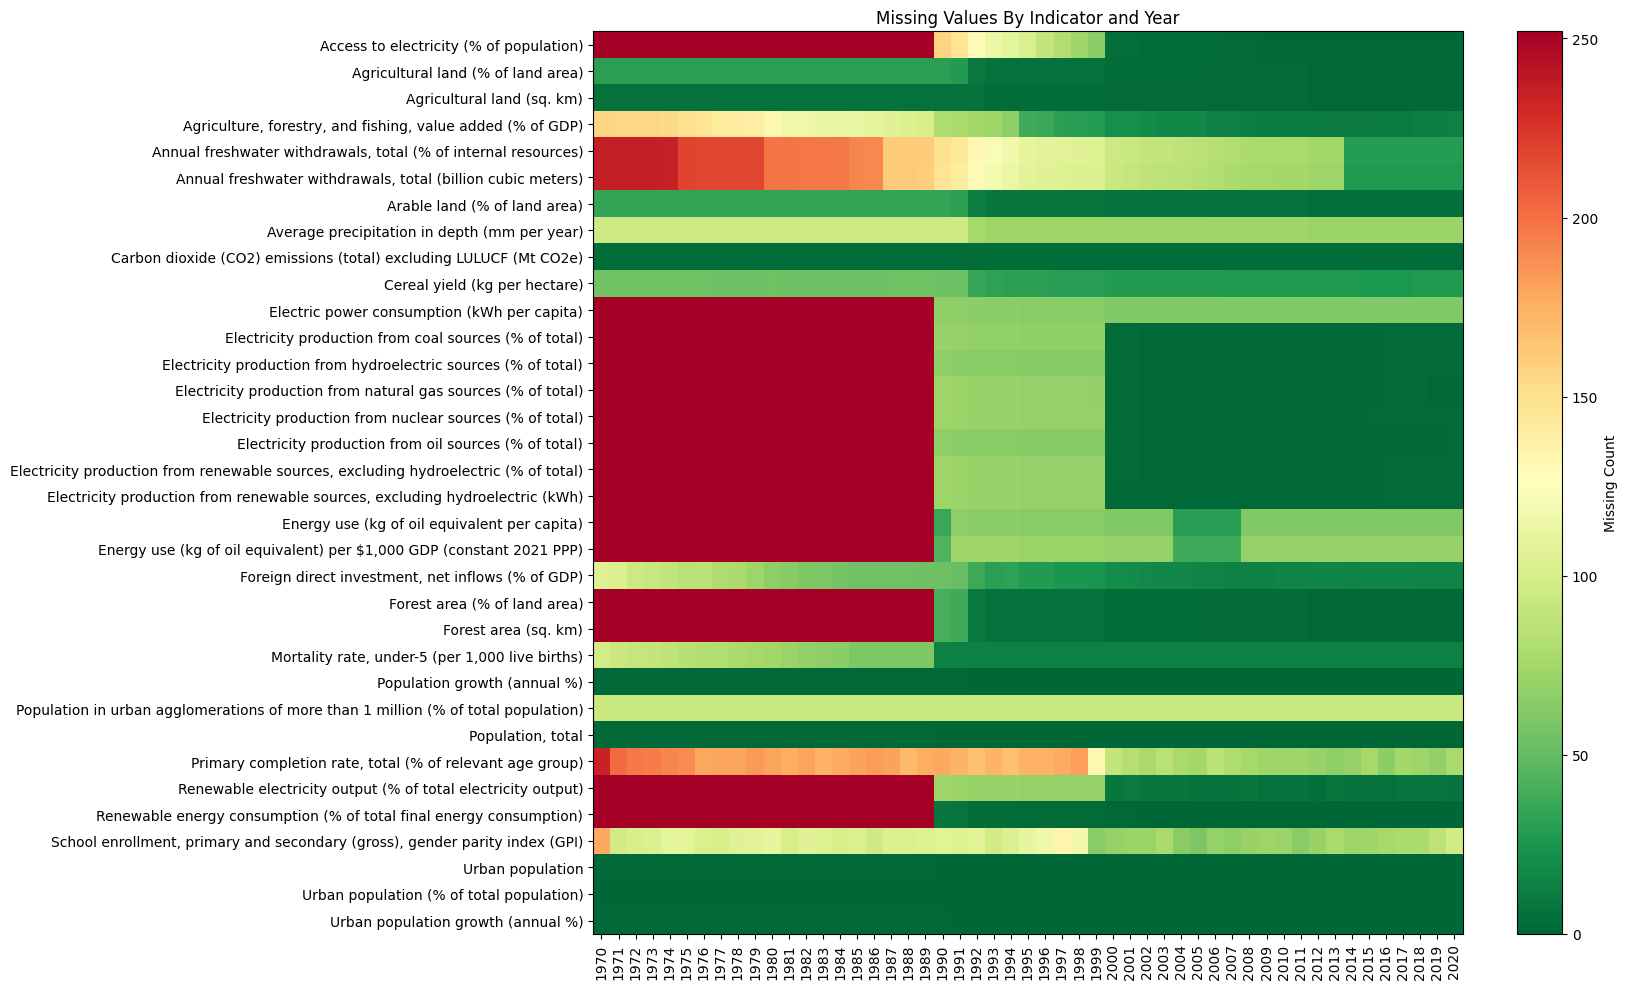

In [16]:
value_cols = train_df.select_dtypes(include="number").columns
value_cols = [c for c in value_cols if c not in ["Year"]]

missing_by_year = (
    train_df
    .groupby("Year")[value_cols]
    .apply(lambda x: x.isna().sum())
)

# Transpose so indicators are on the left, years on the bottom
missing_plot = missing_by_year.T

plt.figure(figsize=(17,10))
plt.imshow(missing_plot, aspect="auto", cmap="RdYlGn_r")
plt.colorbar(label="Missing Count")
plt.xticks(ticks=range(len(missing_plot.columns)), labels=missing_plot.columns, rotation=90)
plt.yticks(ticks=range(len(missing_plot.index)), labels=missing_plot.index)
plt.title("Missing Values By Indicator and Year")
plt.tight_layout()
plt.show()

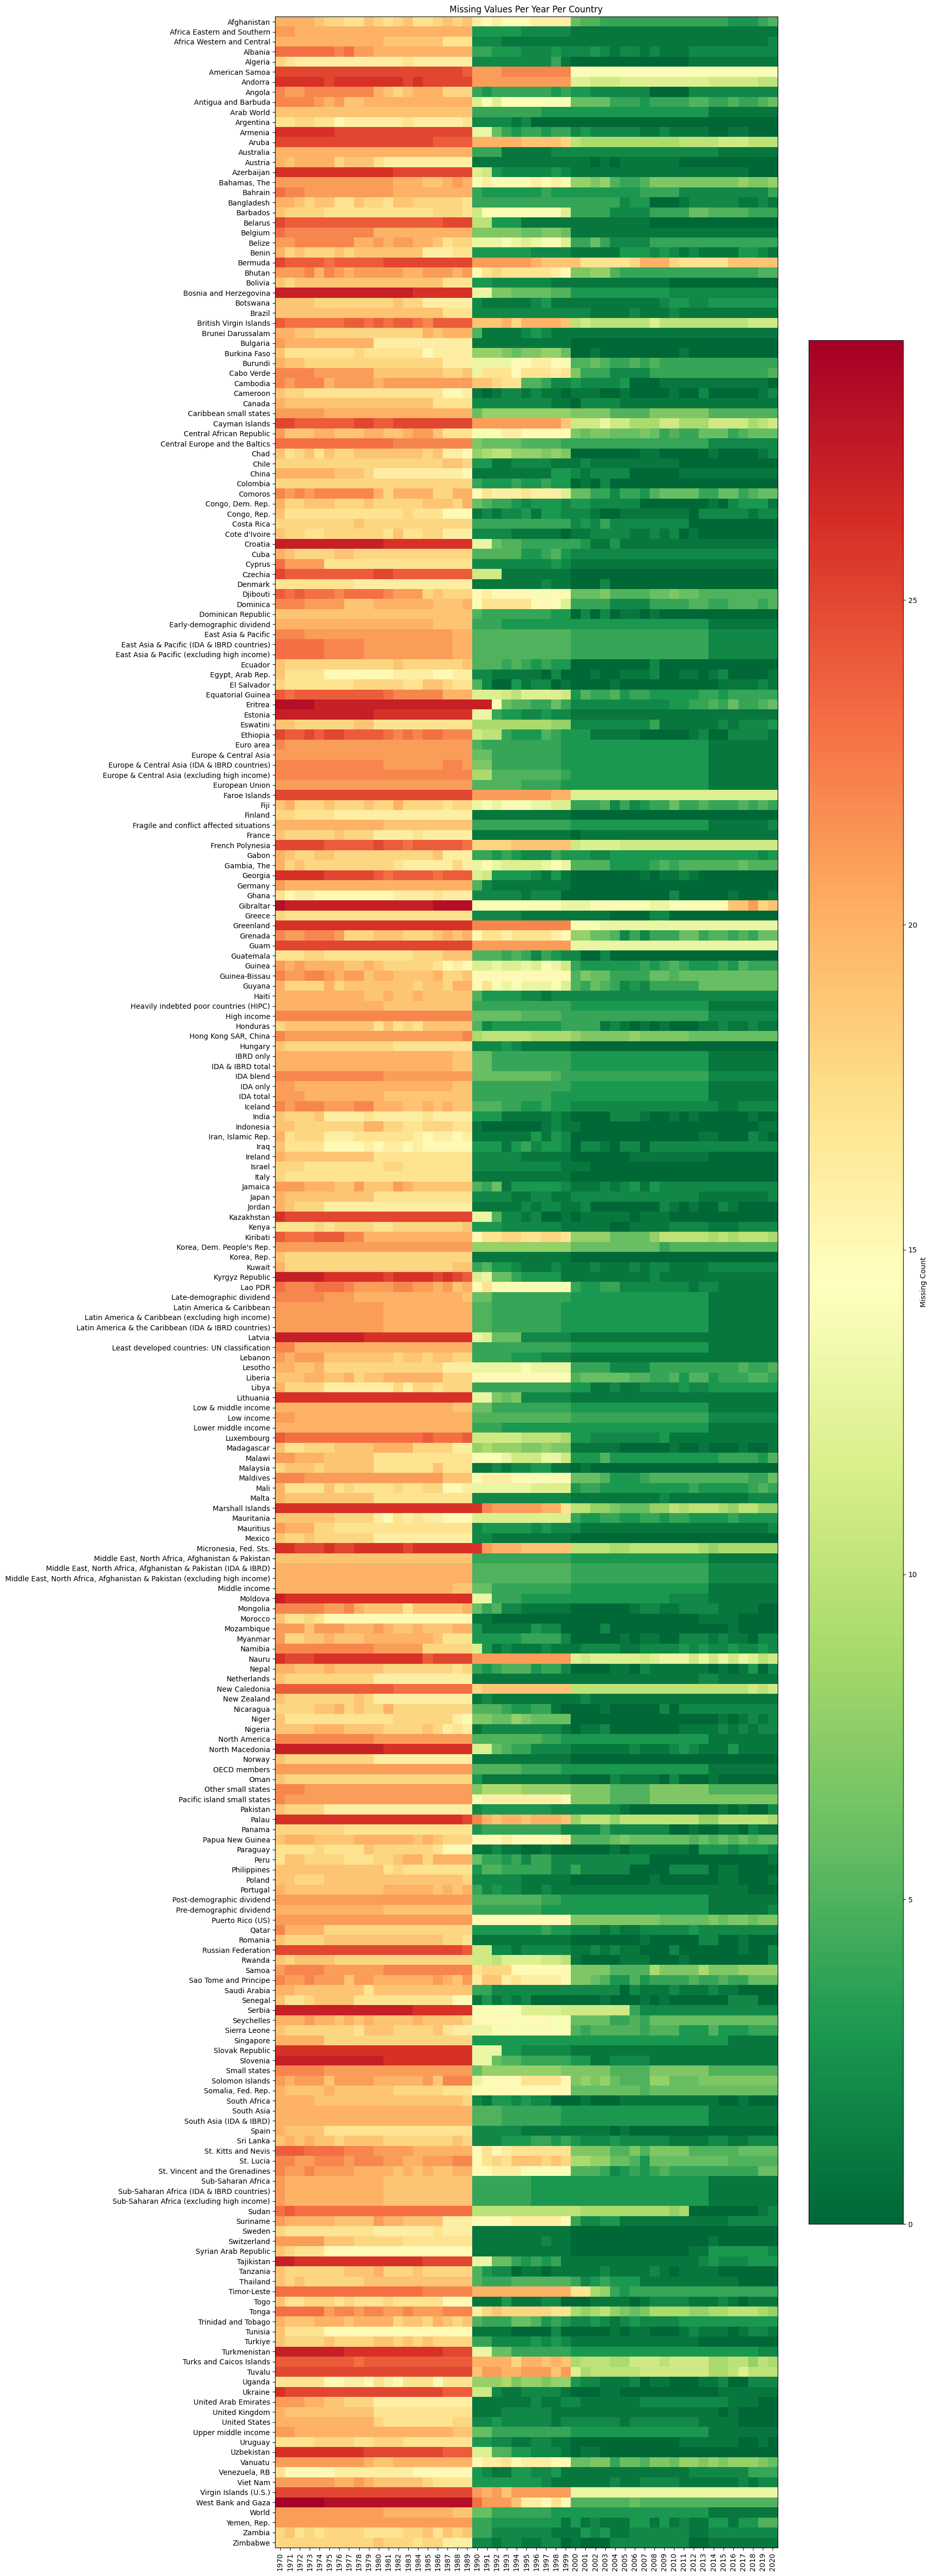

In [17]:
# pick indicator columns (exclude id-like columns)
id_cols = ["Country Name", "Year"]
indicator_cols = [c for c in train_df.columns if c not in id_cols]

# count missing per row, then aggregate by country-year
missing_counts = (
    train_df[indicator_cols]
    .isna()
    .sum(axis=1)
)

missing_by_country_year = (
    train_df[["Country Name", "Year"]]
    .assign(missing=missing_counts)
    .groupby(["Country Name", "Year"])["missing"]
    .sum()
    .unstack("Year")
    .sort_index()
)

# plot heatmap
plt.figure(figsize=(18, 50))
plt.imshow(missing_by_country_year, aspect="auto", cmap="RdYlGn_r")
plt.colorbar(label="Missing Count")
plt.xticks(
    ticks=range(len(missing_by_country_year.columns)),
    labels=missing_by_country_year.columns,
    rotation=90
)
plt.yticks(
    ticks=range(len(missing_by_country_year.index)),
    labels=missing_by_country_year.index
)
plt.title("Missing Values Per Year Per Country")
plt.tight_layout()
plt.show()

In [10]:
years_to_drop = range(1960, 1970)

train_df = train_df[~train_df['Year'].isin(years_to_drop)]

In [11]:
countries_to_drop = [
    "Sint Maarten (Dutch part)",
    "South Sudan",
    "St. Martin (French part)",
    "Monaco",
    "Kosovo",
    "Macao SAR, China",
    "Channel Islands",
    "Montenegro",
    "Curacao",
    "Northern Mariana Islands",
    "Isle of Man",
    "San Marino",
    "Liechtenstein"
]

train_df = train_df[~train_df['Country Name'].isin(countries_to_drop)]

In [12]:
indicatrs_to_drop = [
    "Disaster risk reduction progress score (1-5 scale; 5=best)", 
    "Droughts, floods, extreme temperatures (% of population, average 1990-2009)", 
    "Marine protected areas (% of territorial waters)", 
    "Terrestrial and marine protected areas (% of total territorial area)", 
    "Terrestrial protected areas (% of total land area)", 
    "Community health workers (per 1,000 people)",
    "Agricultural irrigated land (% of total agricultural land)",
    "CPIA public sector management and institutions cluster average (1=low to 6=high)",
    "Land area where elevation is below 5 meters (% of total land area)",
    "Population living in areas where elevation is below 5 meters (% of total population)",
    "Rural land area where elevation is below 5 meters (% of total land area)",
    "Rural land area where elevation is below 5 meters (sq. km)",
    "Rural population living in areas where elevation is below 5 meters (% of total population)",
    "Urban land area where elevation is below 5 meters (% of total land area)",
    "Urban land area where elevation is below 5 meters (sq. km)",
    "Urban population living in areas where elevation is below 5 meters (% of total population)",
    "Prevalence of underweight, weight for age (% of children under 5)",
    "Poverty headcount ratio at $3.00 a day (2021 PPP) (% of population)"
]

train_df = train_df.drop(columns=indicatrs_to_drop)

In [13]:
# year_cols = [c for c in df_indicators.columns if c.isdigit()]
# counts = df_indicators[year_cols].isna().sum()

# plt.figure(figsize=(12,4))
# plt.bar(counts.index, counts.values)
# plt.xticks(rotation=90)
# plt.title('Missing Values By Year')
# plt.xlabel('Year')
# plt.ylabel('Count')
# plt.tight_layout()
# plt.show()

In [14]:
# df_carbon.drop(columns=['Indicator Name', 'Country Code', '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968', '1969', '2025', 'Unnamed: 70'], inplace=True)

In [15]:
# year_cols = [c for c in df_carbon.columns if c.isdigit()]
# df_carbon[year_cols].notna().sum()